In [ ]:
import os
# # Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set project path
project_path = '/content/drive/MyDrive/EE541-project'
os.chdir(project_path)

In [ ]:
import pandas as pd
# Load the data
movies_train_df = pd.read_csv('movies_train_new.csv')
movies_test_df = pd.read_csv('movies_test_new.csv')
movies_train_df = movies_train_df[movies_train_df['vote_count'] != 0]
movies_test_df = movies_test_df[movies_test_df['vote_count'] != 0]
movies_train_df = movies_train_df.dropna(subset=['vote_average'])
movies_test_df = movies_test_df.dropna(subset=['vote_average'])
movies_test_df[:5]

,id,budget,revenue,popularity,genres,keywords,original_title,overview,production_companies,production_countries,spoken_languages,tagline,cast,crew,vote_average,vote_count
0,153035,0,0.0,0.059216,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...","[{'id': 208612, 'name': 'poliziotteschi'}, {'i...",Provincia violenta,"Franco Sereni, a captain of carabiniers, is di...",[],"[{'iso_3166_1': 'IT', 'name': 'Italy'}]","[{'iso_639_1': 'it', 'name': 'Italiano'}]",NaN,"[{'cast_id': 1, 'character': 'Sereni', 'credit...","[{'credit_id': '57acde93c3a3682f1800169f', 'de...",4.0,2.0
1,63888,0,0.0,0.783968,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",[],Mayerling,Crown Prince Rudolf of Austria (Omar Sharif) c...,"[{'name': 'Metro-Goldwyn-Mayer (MGM)', 'id': 8...",[],"[{'iso_639_1': 'en', 'name': 'English'}]",NaN,"[{'cast_id': 2, 'character': 'Archduke Rudolf'...","[{'credit_id': '52fe46bfc3a368484e0a1b89', 'de...",6.6,5.0
2,316152,50000000,25035950.0,10.223582,"[{'id': 10752, 'name': 'War'}, {'id': 28, 'nam...","[{'id': 2831, 'name': 'slavery'}, {'id': 17958...",Free State of Jones,"In 1863, Mississippi farmer Newt Knight serves...","[{'name': 'Larger Than Life Productions', 'id'...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Based on the incredible true story.,"[{'cast_id': 0, 'character': 'Newton Knight', ...","[{'credit_id': '585122c192514175ad009aba', 'de...",6.6,439.0
3,124459,30000000,27437881.0,9.385769,"[{'id': 35, 'name': 'Comedy'}]","[{'id': 2343, 'name': 'magic'}, {'id': 14570, ...",The Incredible Burt Wonderstone,After breaking up with his longtime stage part...,"[{'name': 'New Line Cinema', 'id': 12}, {'name...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}]",Abracatastic!,"[{'cast_id': 5, 'character': 'Burt Wonderstone...","[{'credit_id': '52fe4aacc3a368484e16101b', 'de...",5.3,732.0
4,45220,0,0.0,1.718128,"[{'id': 18, 'name': 'Drama'}, {'id': 10752, 'n...","[{'id': 236, 'name': 'suicide'}, {'id': 836, '...",This Land Is Mine,"In a Nazi-occupied French town, meek and mild-...","[{'name': 'RKO Radio Pictures', 'id': 6}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",A soft-spoken school teacher tries to prove he...,"[{'cast_id': 6, 'character': 'Albert Lory', 'c...","[{'credit_id': '53ca517c0e0a264750001fb0', 'de...",6.6,11.0


In [ ]:
import json
import ast

def to_list(df, feature_names_list):
    """
    Convert JSON-like columns into Python lists, remove `id`, and keep only `name`.
    Handles special cases for `crew` and `cast` columns, limits their size, and cleans up data.

    Args:
        df (pd.DataFrame): Input DataFrame.
        feature_names_list (list): List of feature names to process.

    Returns:
        pd.DataFrame: Processed DataFrame.
    """
    for feature_name in feature_names_list:
        print("Processing feature:", feature_name)

        # STEP 1: Convert JSON format to Python lists safely
        def safe_json_load(x):
            try:
        # If x is a string, attempt to parse it as JSON
                if isinstance(x, str):
                    x = x.replace("'", '"')  # Replace single quotes with double quotes
                    return json.loads(x)
        # If x is already a list (e.g., a Python object), return it as is
                elif isinstance(x, list):
                    return x
                else:
                    return []  # Default to an empty list for other types
            except json.JSONDecodeError:
                try:
            # Use ast.literal_eval as a fallback for malformed JSON strings
                    return ast.literal_eval(x.replace("'", '"'))
                except (ValueError, SyntaxError):
                    return []

        df[feature_name] = df[feature_name].apply(safe_json_load)

        # STEP 2: Special handling for crew and cast columns
        if feature_name == 'crew':  # Limit to most influential crew members
            for index, crew in zip(df.index, df[feature_name]):
                #print(f"Raw crew data: {crew}"
                target_jobs = ['Director', 'Editor', 'Cinematography', 'Writer', 'Music']
                limited_crew = [
                    member["name"] for member in crew
                    if isinstance(member, dict) and "name" in member and "job" in member and member["job"] in target_jobs
                ]
                df.at[index, feature_name] = limited_crew

        elif feature_name == 'cast':  # Limit to top 5 cast members
            for index, cast in zip(df.index, df[feature_name]):
                limited_cast = []
                limit = min(len(cast), 5)  # Max limit of 5 cast members
                for j in range(limit):
                    if "name" in cast[j]:  # Check if 'name' exists in the entry
                        limited_cast.append(cast[j]["name"])
                df.at[index, feature_name] = limited_cast

        else:  # General case: Remove `id` and keep only `name`
            df[feature_name] = df[feature_name].apply(
                lambda x: [item["name"] for item in x if "name" in item]
            )

        # STEP 3: Sort the lists
        df[feature_name] = df[feature_name].apply(
            lambda x: sorted(x) if isinstance(x, list) else ['']
        )

        # STEP 4: Handle empty lists and None values
        df[feature_name] = df[feature_name].apply(
            lambda x: x if len(x) > 0 else ['']
        )

    return df

movies_train = to_list(movies_train_df, ['genres', 'keywords', 'production_companies','spoken_languages','production_countries','cast','crew'])
movies_test = to_list(movies_test_df,  ['genres', 'keywords', 'production_companies','spoken_languages','production_countries','cast','crew'])
# Select the columns you want
movies_train_df_selected = movies_train[['genres', 'keywords', 'production_companies', 'spoken_languages','production_countries','cast','crew']]
movies_test_df_selected = movies_test[['genres', 'keywords', 'production_companies', 'spoken_languages','production_countries','cast','crew']]
movies_test[:5]

Processing feature: genres
Processing feature: keywords
Processing feature: production_companies
Processing feature: spoken_languages
Processing feature: production_countries
Processing feature: cast
Processing feature: crew
Processing feature: genres
Processing feature: keywords
Processing feature: production_companies
Processing feature: spoken_languages
Processing feature: production_countries
Processing feature: cast
Processing feature: crew


,id,budget,revenue,popularity,genres,keywords,original_title,overview,production_companies,production_countries,spoken_languages,tagline,cast,crew,vote_average,vote_count
0,153035,0,0.0,0.059216,"[Action, Crime, Drama]","[eurocrime, poliziotteschi]",Provincia violenta,"Franco Sereni, a captain of carabiniers, is di...",[],[Italy],[Italiano],NaN,"[Al Cliver, Alicia Leoni, Antonella Dogan, Cal...","[Mario Bianchi, Mario Bianchi, Maurizio Tedesc...",4.0,2.0
1,63888,0,0.0,0.783968,"[Drama, Romance]",[],Mayerling,Crown Prince Rudolf of Austria (Omar Sharif) c...,[Metro-Goldwyn-Mayer (MGM)],[],[English],NaN,"[Ava Gardner, Catherine Deneuve, James Mason, ...","[Claude Anet, Terence Young]",6.6,5.0
2,316152,50000000,25035950.0,10.223582,"[Action, Drama, History, Thriller, War]","[american civil war, slavery]",Free State of Jones,"In 1863, Mississippi farmer Newt Knight serves...","[Larger Than Life Productions, Route One Films...",[United States of America],"[Deutsch, English]",Based on the incredible true story.,"[Gugu Mbatha-Raw, Jacob Lofland, Keri Russell,...","[Gary Ross, Gary Ross, Juliette Welfling, Nich...",6.6,439.0
3,124459,30000000,27437881.0,9.385769,[Comedy],"[las vegas, magic]",The Incredible Burt Wonderstone,After breaking up with his longtime stage part...,"[Benderspink, Carousel Productions, New Line C...",[United States of America],[English],Abracatastic!,"[James Gandolfini, Jim Carrey, Olivia Wilde, S...","[Chad Kultgen, Don Scardino, John Francis Dale...",5.3,732.0
4,45220,0,0.0,1.718128,"[Drama, War]","[air raid, bravery, cigarette smoking, hand gr...",This Land Is Mine,"In a Nazi-occupied French town, meek and mild-...","[Jean-Renoir- Dudly Nichols Productions, RKO R...",[United States of America],"[Deutsch, English, Latin]",A soft-spoken school teacher tries to prove he...,[],[],6.6,11.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_list(df, column_name):
    """
    Generate a sorted list of unique feature values from a specified column, based on their associated average ratings.

    Args:
        df (pd.DataFrame): Input DataFrame.
        column_name (str): Name of the column to process.

    Returns:
        list: Sorted list of feature names from lowest to highest average rating.
    """
    # Step 1: Track all ratings associated with each feature in a dictionary
    rating_dict = {}
    for _, row in df.iterrows():
        features = row[column_name]
        for feature in features:
            if feature not in rating_dict:
                rating_dict[feature] = (row['vote_average'], 1)
            else:
                rating_dict[feature] = (
                    rating_dict[feature][0] + row['vote_average'],
                    rating_dict[feature][1] + 1,
                )

    # Step 2: Calculate average ratings for each feature
    for feature in rating_dict:
        total_rating, count = rating_dict[feature]
        rating_dict[feature] = total_rating / count

    # Step 3: Create and sort a list of tuples (average rating, feature name)
    sorted_features = sorted((rating, feature) for feature, rating in rating_dict.items())

    # Step 4: Separate feature names and ratings into individual lists
    feature_list = [feature for _, feature in sorted_features]
    ratings_list = [rating for rating, _ in sorted_features]

    return feature_list



# Combine training and testing data
movies_combined_df = pd.concat([movies_train_df, movies_test_df], ignore_index=True)

genres_list = generate_list(movies_combined_df, 'genres')
keywords_list = generate_list(movies_combined_df, 'keywords')
production_companies_list = generate_list(movies_combined_df, 'production_companies')
spoken_languages_list = generate_list(movies_combined_df, 'spoken_languages')
production_countries_list = generate_list(movies_combined_df, 'production_countries')
cast_list = generate_list(movies_combined_df, 'cast')
crew_list = generate_list(movies_combined_df, 'crew')

In [ ]:
len(keywords_list)
genres_list

['Horror',
 'Science Fiction',
 'TV Movie',
 'Western',
 'Thriller',
 'Action',
 'Adventure',
 'Fantasy',
 'Family',
 'Comedy',
 'Mystery',
 'Foreign',
 '',
 'Romance',
 'Crime',
 'Drama',
 'War',
 'Music',
 'History',
 'Animation',
 'Documentary']

In [ ]:
def calculate_bin_array(current_features, all_possible_features):
    return [1 if feature in current_features else 0 for feature in all_possible_features]

# Apply to the DataFrame columns
movies_train_df_selected['genres'] = movies_train_df_selected['genres'].apply(lambda x: calculate_bin_array(x, genres_list))
movies_train_df_selected['production_companies'] = movies_train_df_selected['production_companies'].apply(lambda x: calculate_bin_array(x, production_companies_list))
movies_train_df_selected['spoken_languages'] = movies_train_df_selected['spoken_languages'].apply(lambda x: calculate_bin_array(x, spoken_languages_list))
movies_train_df_selected['production_countries'] = movies_train_df_selected['production_countries'].apply(lambda x: calculate_bin_array(x, production_countries_list))
movies_train_df_selected['keywords'] = movies_train_df_selected['keywords'].apply(lambda x: calculate_bin_array(x, keywords_list))
movies_train_df_selected['cast'] = movies_train_df_selected['cast'].apply(lambda x: calculate_bin_array(x, cast_list))
movies_train_df_selected['crew'] = movies_train_df_selected['crew'].apply(lambda x: calculate_bin_array(x, crew_list))

movies_test_df_selected['production_companies'] = movies_test_df_selected['production_companies'].apply(lambda x: calculate_bin_array(x, production_companies_list))
movies_test_df_selected['spoken_languages'] = movies_test_df_selected['spoken_languages'].apply(lambda x: calculate_bin_array(x, spoken_languages_list))
movies_test_df_selected['production_countries'] = movies_test_df_selected['production_countries'].apply(lambda x: calculate_bin_array(x, production_countries_list))
movies_test_df_selected['genres'] = movies_test_df_selected['genres'].apply(lambda x: calculate_bin_array(x, genres_list))
movies_test_df_selected['keywords'] = movies_test_df_selected['keywords'].apply(lambda x: calculate_bin_array(x, keywords_list))
movies_test_df_selected['cast'] = movies_test_df_selected['cast'].apply(lambda x: calculate_bin_array(x, cast_list))
movies_test_df_selected['crew'] = movies_test_df_selected['crew'].apply(lambda x: calculate_bin_array(x, crew_list))


movies_train_df_selected[:10]


/tmp/ipykernel_198/2222120184.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_train_df_selected['genres'] = movies_train_df_selected['genres'].apply(lambda x: calculate_bin_array(x, genres_list))
/tmp/ipykernel_198/2222120184.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_train_df_selected['production_companies'] = movies_train_df_selected['production_companies'].apply(lambda x: calculate_bin_array(x, production_companies_list))
/tmp/ipykernel_198/2222120184.py:7: SettingWithCopyWarni

,genres,keywords,production_companies,spoken_languages,production_countries,cast,crew
0,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,"[1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,"[1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,"[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
keywords = movies_train_df_selected['keywords'][0]
positions = [i for i, val in enumerate(keywords) if val == 1]
movies_test_df_selected[:10]

为 1 的位置是： [7487, 8571, 11410, 12821]


,genres,keywords,production_companies,spoken_languages,production_countries,cast,crew
0,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,"[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,"[0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,"[0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
10,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
def to_concentrations(df, feature_columns, n=10):

    for column in feature_columns:
        print('Processing feature:', column)

        def find_concentration(array):
            """
            Calculate concentration points and the number of '1's in each segment of the array.

            Args:
                array (list): Binary array (contains 0s and 1s).

            Returns:
                list: List of tuples (average position of '1's, count of '1's) for each segment.
            """
            # Divide the array into n segments
            batch_size = len(array) // n
            batches = [array[i:i + batch_size] for i in range(0, len(array), batch_size)]

            concentrations = []
            for batch_index, batch in enumerate(batches):
                total_position = 0
                count_ones = 0

                # Accumulate the positions of '1's in the current batch
                for position_in_batch, value in enumerate(batch):
                    if value == 1:
                        global_position = position_in_batch + batch_index * batch_size  # Adjust for global position
                        total_position += global_position
                        count_ones += 1

                # Calculate the average position if there are '1's in the batch
                if count_ones > 0:
                    average_position = total_position / count_ones
                    concentrations.append((average_position, count_ones))

            return concentrations

        # Apply the concentration calculation to the specified column
        df[column] = df[column].apply(find_concentration)

    return df

movies_train_df_selected = to_concentrations(
    movies_train_df_selected,
    ['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast', 'crew']
)

movies_test_df_selected = to_concentrations(
    movies_test_df_selected,
    ['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast', 'crew']
)

movies_train_df_selected[:10]

Processing feature: genres
Processing feature: keywords


/tmp/ipykernel_198/2837824265.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].apply(find_concentration)


Processing feature: production_companies
Processing feature: spoken_languages
Processing feature: production_countries
Processing feature: cast
Processing feature: crew
Processing feature: genres
Processing feature: keywords
Processing feature: production_companies
Processing feature: spoken_languages
Processing feature: production_countries
Processing feature: cast
Processing feature: crew


,genres,keywords,production_companies,spoken_languages,production_countries,cast,crew
0,"[(0.0, 1), (9.0, 1), (15.0, 1)]","[(7487.0, 1), (8571.0, 1), (11410.0, 1), (1282...","[(20124.0, 1)]","[(49.0, 1)]","[(101.0, 1)]","[(30196.0, 1)]","[(28960.5, 2), (36157.0, 1)]"
1,"[(0.0, 1), (4.0, 1), (10.0, 1)]","[(2616.0, 1), (7383.0, 1), (9659.5, 2), (15179...","[(14034.0, 1)]","[(4.0, 1)]","[(32.0, 1)]","[(30196.0, 1)]","[(22262.0, 1)]"
2,"[(4.0, 1), (10.0, 1), (14.5, 2)]","[(1456.0, 1), (10736.0, 1)]","[(10983.0, 1), (11677.0, 1), (13654.0, 1)]","[(4.0, 1)]","[(65.0, 1)]","[(32535.0, 3), (37524.5, 2)]","[(23604.0, 1)]"
3,"[(0.0, 1), (4.0, 1), (7.0, 1), (10.0, 1), (15....","[(3485.0, 1), (5235.666666666667, 3), (6296.0,...","[(986.0, 1), (6496.0, 1), (11586.0, 1)]","[(4.0, 1)]","[(32.0, 1)]","[(30196.0, 1)]","[(10345.0, 1), (24818.0, 1)]"
4,"[(0.5, 2), (4.0, 1), (7.0, 1), (10.0, 1), (15....","[(3096.5, 2), (4196.0, 1), (6533.0, 5), (8712....","[(11666.0, 1)]","[(4.0, 1), (18.0, 1)]","[(32.0, 1)]","[(5905.0, 1), (21325.0, 1), (29982.0, 2), (356...","[(18876.0, 1), (31242.0, 1)]"
5,"[(12.0, 1)]","[(6016.0, 1)]","[(9536.0, 1)]","[(4.0, 1)]","[(32.0, 1)]","[(17051.0, 1), (21270.0, 1), (24692.5, 2), (41...","[(9619.0, 1)]"
6,"[(15.0, 1)]","[(10726.0, 2), (17777.0, 1)]","[(10737.0, 1), (14565.0, 1), (19885.0, 1)]","[(4.0, 1)]","[(32.0, 1)]","[(30196.0, 1)]","[(25434.0, 1), (36221.0, 1)]"
7,"[(4.0, 1), (15.0, 1)]","[(4514.0, 1), (9022.42857142857, 7), (10702.0,...","[(5376.0, 1), (10807.0, 1)]","[(4.0, 1), (15.0, 1), (46.0, 1)]","[(32.0, 1)]","[(30196.0, 1)]","[(21109.0, 1)]"
8,"[(4.5, 2), (14.5, 2)]","[(4707.666666666667, 3), (7358.0, 1), (9097.66...","[(11373.0, 1), (15404.0, 1)]","[(6.0, 1)]","[(38.0, 1)]","[(30992.4, 5)]","[(13890.0, 1), (17241.0, 1)]"
9,"[(5.0, 1), (9.0, 1)]","[(6016.0, 1)]","[(6591.0, 1)]","[(4.0, 1)]","[(65.0, 1)]","[(18945.5, 2), (24314.0, 1), (31641.0, 2)]","[(13133.0, 1)]"


In [ ]:
movies_test_df_selected[:10]

,genres,keywords,production_companies,spoken_languages,production_countries,cast,crew
0,"[(5.0, 1), (14.5, 2)]","[(394.0, 1), (7453.0, 1)]","[(9536.0, 1)]","[(15.0, 1)]","[(49.0, 1)]","[(3812.6666666666665, 3), (7688.0, 1), (34083....","[(4857.0, 1), (10889.5, 2), (14892.0, 1)]"
1,"[(13.0, 1), (15.0, 1)]","[(6016.0, 1)]","[(9598.0, 1)]","[(4.0, 1)]","[(31.0, 1)]","[(30907.666666666668, 3), (37766.0, 1), (39916...","[(17661.0, 1), (28695.0, 1)]"
2,"[(4.5, 2), (15.0, 1), (16.0, 1), (18.0, 1)]","[(7096.0, 1), (8369.0, 1)]","[(14366.0, 2), (17090.0, 1)]","[(4.0, 1), (19.0, 1)]","[(32.0, 1)]","[(21136.0, 1), (33722.0, 2), (47769.0, 2)]","[(22346.0, 1), (30707.666666666668, 3)]"
3,"[(9.0, 1)]","[(3043.0, 1), (7356.0, 1)]","[(4938.0, 2), (9513.0, 1)]","[(4.0, 1)]","[(32.0, 1)]","[(21576.0, 1), (24672.0, 1), (29517.0, 1), (35...","[(10594.0, 2), (17155.0, 3)]"
4,"[(15.0, 1), (16.0, 1)]","[(6790.0, 1), (8666.75, 4), (10877.33333333333...","[(9519.0, 1), (15882.0, 1)]","[(4.0, 1), (19.0, 1), (62.0, 1)]","[(32.0, 1)]","[(30196.0, 1)]","[(21109.0, 1)]"
5,"[(12.0, 1)]","[(6016.0, 1)]","[(9536.0, 1)]","[(9.0, 1)]","[(31.0, 1)]","[(30196.0, 1)]","[(30760.0, 1)]"
6,"[(2.0, 1), (10.0, 1), (13.0, 1), (15.0, 1)]","[(6016.0, 1)]","[(3943.0, 1), (5975.0, 1), (8446.0, 1)]","[(4.0, 1)]","[(26.0, 1)]","[(9405.0, 1), (14788.333333333334, 3), (24853....","[(12317.0, 1), (16927.0, 1), (21036.0, 1)]"
8,"[(6.0, 1), (8.5, 2), (19.0, 1)]","[(3000.0, 1), (11270.0, 1)]","[(7982.0, 1), (10744.5, 2)]","[(4.0, 1), (56.0, 1)]","[(32.0, 1)]","[(19968.0, 1), (29810.5, 2), (35616.0, 2)]","[(23347.0, 2), (28184.0, 1)]"
9,"[(1.0, 1), (3.0, 1), (5.0, 1)]","[(7460.0, 1), (10526.0, 1)]","[(3264.0, 1)]","[(4.0, 1)]","[(32.0, 1)]","[(30196.0, 1)]","[(11292.0, 1), (13257.5, 4)]"
10,"[(15.0, 1)]","[(3626.0, 1), (5411.666666666667, 3), (7316.0,...","[(4123.0, 1), (7330.0, 1)]","[(4.0, 1)]","[(32.0, 1)]","[(14329.333333333334, 3), (19148.0, 1), (26764...","[(10335.0, 2)]"


In [ ]:
def to_weighted_avg(df, feature_columns, vote_average_column, n=None):
    """
    Process specified columns in a DataFrame to compute weighted averages
    and add the `vote_average` column from the original DataFrame.

    Args:
        df (pd.DataFrame): Input DataFrame containing feature columns with lists of tuples.
        feature_columns (list): List of column names to compute weighted averages.
        vote_average_column (pd.Series): Original `vote_average` column to append to the DataFrame.

    Returns:
        pd.DataFrame: Updated DataFrame with weighted averages in specified columns
                      and the `vote_average` column added.
    """
    for column in feature_columns:
        print(f"Processing feature: {column}")

        # Process the weighted average directly inside the loop
        df[column] = df[column].apply(
            lambda arr: sum(pos * wt for pos, wt in arr) / sum(wt for _, wt in arr) if sum(wt for _, wt in arr) > 0 else 0
        )

    # Add the `vote_average` column
    df['vote_average'] = vote_average_column

    return df


# Apply the function
movies_train_df_selected = to_weighted_avg(
    movies_train_df_selected,
    ['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast', 'crew'],
    movies_train_df['vote_average']
)

movies_test_df_selected = to_weighted_avg(
    movies_test_df_selected,
    ['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew'],
    movies_test_df['vote_average']
)

movies_train_df_selected[:10]


Processing feature: genres
Processing feature: keywords
Processing feature: production_companies


/tmp/ipykernel_198/2397281675.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].apply(


Processing feature: spoken_languages
Processing feature: production_countries
Processing feature: cast
Processing feature: crew
Processing feature: genres
Processing feature: keywords
Processing feature: production_companies
Processing feature: spoken_languages


/tmp/ipykernel_198/2397281675.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['vote_average'] = vote_average_column
/tmp/ipykernel_198/2397281675.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].apply(


Processing feature: production_countries
Processing feature: cast
Processing feature: crew


/tmp/ipykernel_198/2397281675.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['vote_average'] = vote_average_column


,genres,keywords,production_companies,spoken_languages,production_countries,cast,crew,vote_average
0,8.000000,10072.250000,20124.000000,49.000000,101.0,30196.0,31359.333333,7.3
1,4.666667,8899.400000,14034.000000,4.000000,32.0,30196.0,22262.000000,6.4
2,10.750000,6096.000000,12104.666667,4.000000,65.0,34530.8,23604.000000,6.6
3,7.200000,5613.833333,6356.000000,4.000000,32.0,30196.0,17581.500000,5.2
4,6.166667,9047.500000,11666.000000,11.000000,32.0,24560.4,25059.000000,6.7
5,12.000000,6016.000000,9536.000000,4.000000,32.0,25884.2,9619.000000,6.7
6,15.000000,13076.333333,15062.333333,4.000000,32.0,30196.0,30827.500000,7.3
7,9.500000,9012.900000,8091.500000,21.666667,32.0,30196.0,21109.000000,6.0
8,9.500000,8925.000000,13388.500000,6.000000,38.0,30992.4,15565.500000,6.1
9,7.000000,6016.000000,6591.000000,4.000000,65.0,25097.4,13133.000000,5.5


In [ ]:
movies_test_df_selected.sample(10)

,genres,keywords,production_companies,spoken_languages,production_countries,cast,crew,vote_average
375,15.000000,9463.714286,9536.000000,19.0,64.0,34752.0,15548.0,6.4
12508,9.600000,6086.000000,9429.000000,11.0,32.0,24849.2,17724.5,5.5
7465,7.500000,9253.000000,10983.000000,14.0,32.0,25377.8,16891.0,5.6
11633,14.000000,4165.500000,3421.500000,4.0,32.0,18250.4,10822.0,4.4
12942,20.000000,18111.000000,19160.666667,4.0,26.0,51415.5,35677.0,7.4
848,18.500000,7369.666667,9536.000000,9.0,31.0,30196.0,21109.0,6.3
8676,14.000000,12478.875000,16549.500000,4.0,48.5,30196.0,25781.5,6.5
1850,6.800000,6016.000000,12188.000000,42.5,85.0,36177.4,25482.0,6.2
1783,13.000000,7983.000000,11807.000000,4.0,31.0,30738.2,26950.0,6.5
10055,16.333333,15840.333333,16234.000000,19.0,64.0,30196.0,25410.0,7.0


#Reduce Dim

In [ ]:
from sklearn.decomposition import PCA

def apply_pca_to_numeric_data(train_df, test_df, feature_columns, n_components=2):
    """
    Apply PCA to specified numeric columns of both training and testing datasets.

    Args:
        train_df (pd.DataFrame): Training DataFrame containing numeric features.
        test_df (pd.DataFrame): Testing DataFrame containing numeric features.
        feature_columns (list): List of numeric column names to apply PCA on.
        n_components (int): Number of PCA components to keep.

    Returns:
        pd.DataFrame, pd.DataFrame: Updated training and testing DataFrames with PCA components added.
    """
    # Extract feature matrices from the specified columns
    X_train = train_df[feature_columns].values
    X_test = test_df[feature_columns].values

    # Fit PCA on the training data and transform both datasets
    print(f"Applying PCA with {n_components} components on numeric data...")
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)  # Use the same PCA model for the test set

    # Add PCA components as new columns to the DataFrames
    for i in range(n_components):
        train_df[f'PCA_component_{i+1}'] = X_train_pca[:, i]
        test_df[f'PCA_component_{i+1}'] = X_test_pca[:, i]

    print("PCA explained variance ratio:", pca.explained_variance_ratio_)
    return train_df, test_df

# Choose the columns to apply PCA
feature_columns = ['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']

# 在训练集和测试集上应用 PCA
movies_train_df_selected, movies_test_df_selected = apply_pca_to_numeric_data(
    movies_train_df_selected,
    movies_test_df_selected,
    feature_columns=feature_columns,
    n_components=5
)

# 查看更新后的训练集和测试集
movies_train_df_selected.head(10)
movies_test_df_selected.head(10)


#PCA-MLP

Epoch [10/500], Train Loss: 24.8747
Epoch [20/500], Train Loss: 4.0165
Epoch [30/500], Train Loss: 2.7402
Epoch [40/500], Train Loss: 1.2821
Epoch [50/500], Train Loss: 0.7390
Epoch [60/500], Train Loss: 0.7053
Epoch [70/500], Train Loss: 0.6814
Epoch [80/500], Train Loss: 0.6528
Epoch [90/500], Train Loss: 0.6431
Epoch [100/500], Train Loss: 0.6295
Epoch [110/500], Train Loss: 0.6218
Epoch [120/500], Train Loss: 0.6198
Epoch [130/500], Train Loss: 0.6122
Epoch [140/500], Train Loss: 0.6012
Epoch [150/500], Train Loss: 0.5942
Epoch [160/500], Train Loss: 0.5858
Epoch [170/500], Train Loss: 0.5750
Epoch [180/500], Train Loss: 0.5647
Epoch [190/500], Train Loss: 0.5528
Epoch [200/500], Train Loss: 0.5476
Epoch [210/500], Train Loss: 0.5415
Epoch [220/500], Train Loss: 0.5349
Epoch [230/500], Train Loss: 0.5305
Epoch [240/500], Train Loss: 0.5234
Epoch [250/500], Train Loss: 0.5188
Epoch [260/500], Train Loss: 0.5157
Epoch [270/500], Train Loss: 0.5070
Epoch [280/500], Train Loss: 0.5012


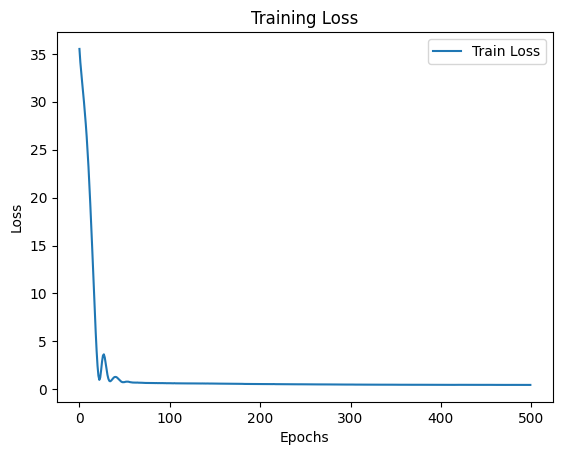

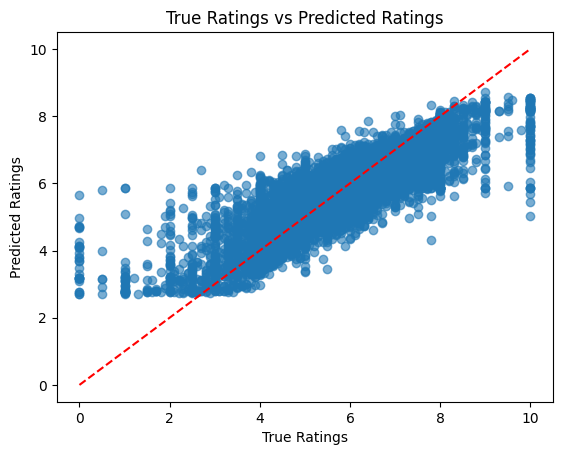

Mean Squared Error: 0.4638
R^2 Score for predictions: 0.7240900970789821


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# 数据准备
# 使用 PCA 特征代替原始特征
pca_features = [col for col in movies_train_df_selected.columns if col.startswith('PCA_component')]
X = movies_train_df_selected[pca_features].values
y = movies_train_df_selected['vote_average'].values

# 转换为 NumPy 数组
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

# 数据标准化
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# 转换为 Tensor
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # 增加维度

# 改进的 MLP 模型定义
class ImprovedMLP(nn.Module):
    def __init__(self, input_size):
        super(ImprovedMLP, self).__init__()

        # 主分支网络
        self.main_branch = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU()
        )

        # 辅助分支网络
        self.aux_branch = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU()
        )

        # 输出层
        self.output_layer = nn.Sequential(
            nn.Linear(32 + 32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        # 主分支输出
        main_output = self.main_branch(x)

        # 辅助分支输出
        aux_output = self.aux_branch(x)

        # 融合主分支和辅助分支的输出
        combined_output = torch.cat((main_output, aux_output), dim=1)

        # 输出层处理
        return self.output_layer(combined_output)

# 初始化改进版 MLP
input_size = X.shape[1]  # PCA 特征数量
model = ImprovedMLP(input_size)

# 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.004, weight_decay=1e-3)

# 训练模型
num_epochs = 500
train_losses = []

for epoch in range(num_epochs):
    model.train()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}')

# 可视化训练损失
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss')
plt.show()

# 测试模型
X_test = movies_test_df_selected[pca_features].values
y_test_true = movies_test_df_selected['vote_average'].values

# 转换为 NumPy 数组并标准化
X_test = np.array(X_test, dtype=np.float32)
X_test = scaler.transform(X_test)

# 转换为 Tensor
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor).numpy()

# 可视化真实值 vs 预测值
plt.scatter(y_test_true, predictions, alpha=0.6)
plt.plot([0, 10], [0, 10], 'r--')  # 参考线
plt.xlabel('True Ratings')
plt.ylabel('Predicted Ratings')
plt.title('True Ratings vs Predicted Ratings')
plt.show()

# 打印均方误差
mse = mean_squared_error(y_test_true, predictions)
score = r2_score(y_test_true, predictions)
print(f'Mean Squared Error: {mse:.4f}')
print("R^2 Score for predictions:", score)

#PCA-Attention

Epoch [10/500], Train Loss: 3.9964
Epoch [20/500], Train Loss: 2.1799
Epoch [30/500], Train Loss: 1.0303
Epoch [40/500], Train Loss: 0.9207
Epoch [50/500], Train Loss: 0.8204
Epoch [60/500], Train Loss: 0.7345
Epoch [70/500], Train Loss: 0.6947
Epoch [80/500], Train Loss: 0.6911
Epoch [90/500], Train Loss: 0.6822
Epoch [100/500], Train Loss: 0.6732
Epoch [110/500], Train Loss: 0.6679
Epoch [120/500], Train Loss: 0.6538
Epoch [130/500], Train Loss: 0.6343
Epoch [140/500], Train Loss: 0.6255
Epoch [150/500], Train Loss: 0.6070
Epoch [160/500], Train Loss: 0.6083
Epoch [170/500], Train Loss: 0.5962
Epoch [180/500], Train Loss: 0.5897
Epoch [190/500], Train Loss: 0.5851
Epoch [200/500], Train Loss: 0.5800
Epoch [210/500], Train Loss: 0.5751
Epoch [220/500], Train Loss: 0.5697
Epoch [230/500], Train Loss: 0.5651
Epoch [240/500], Train Loss: 0.5596
Epoch [250/500], Train Loss: 0.5482
Epoch [260/500], Train Loss: 0.5507
Epoch [270/500], Train Loss: 0.5404
Epoch [280/500], Train Loss: 0.5352
E

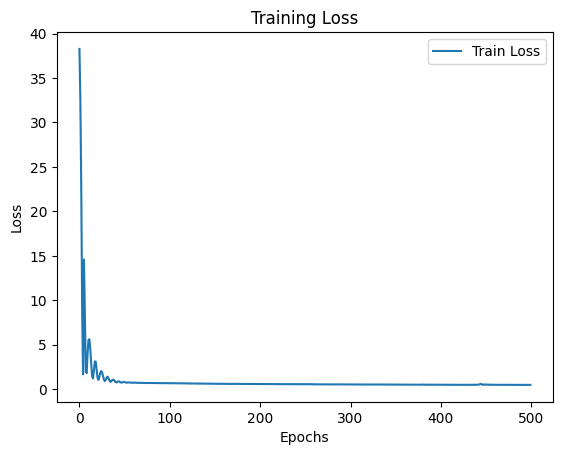

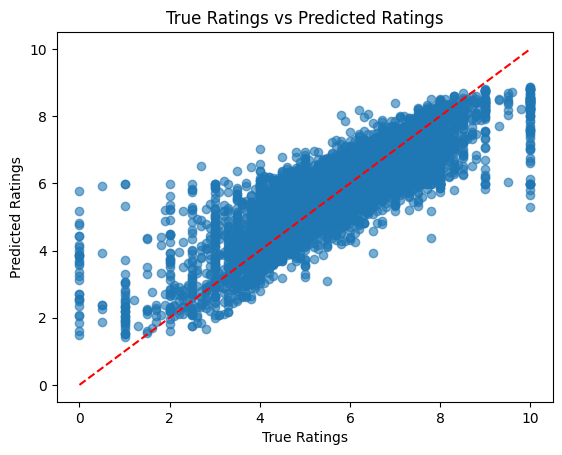

Mean Squared Error: 0.4380
R^2 Score for predictions: 0.7394809138729763


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# 数据准备
pca_features = [col for col in movies_train_df_selected.columns if col.startswith('PCA_component')]
X = movies_train_df_selected[pca_features].values
y = movies_train_df_selected['vote_average'].values

# 转换为 NumPy 数组
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

# 数据标准化
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# 转换为 Tensor
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # 增加维度

# 改进的 Attention 模型定义
class ImprovedAttentionModel(nn.Module):
    def __init__(self, input_size, embed_dim, num_heads, hidden_dim, num_layers):
        super(ImprovedAttentionModel, self).__init__()

        # 主分支网络：Attention 提取特征
        self.main_attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=0.3, batch_first=True)
        self.main_fc = nn.Sequential(
            nn.Linear(input_size, embed_dim),  # 初始映射到 embed_dim
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )

        # 辅助分支网络：简单的全连接层
        self.aux_branch = nn.Sequential(
            nn.Linear(input_size, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        # 输出层
        self.output_layer = nn.Sequential(
            nn.Linear(embed_dim + hidden_dim, 64),  # 融合主分支和辅助分支
            nn.ReLU(),
            nn.Linear(64, 1)  # 最终输出
        )

    def forward(self, x):
        # 主分支：使用 Attention
        x_embedded = self.main_fc(x).unsqueeze(1)  # 增加序列维度
        main_output, _ = self.main_attention(x_embedded, x_embedded, x_embedded)
        main_output = main_output.squeeze(1)  # 移除序列维度

        # 辅助分支
        aux_output = self.aux_branch(x)

        # 融合主分支和辅助分支
        combined_output = torch.cat((main_output, aux_output), dim=1)

        # 输出层处理
        return self.output_layer(combined_output)

# 初始化改进版 Attention 模型
input_size = X.shape[1]  # 输入特征数量
embed_dim = 64  # Attention 的嵌入维度
num_heads = 4  # Attention 头数
hidden_dim = 256  # 辅助分支隐藏层维度
num_layers = 4  # 可选：用于深层网络
model = ImprovedAttentionModel(input_size, embed_dim, num_heads, hidden_dim, num_layers)

# 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# 训练模型
num_epochs = 500
train_losses = []

for epoch in range(num_epochs):
    model.train()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}')

# 可视化训练损失
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss')
plt.show()

# 测试模型
X_test = movies_test_df_selected[pca_features].values
y_test_true = movies_test_df_selected['vote_average'].values

# 转换为 NumPy 数组并标准化
X_test = np.array(X_test, dtype=np.float32)
X_test = scaler.transform(X_test)

# 转换为 Tensor
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor).numpy()

# 可视化真实值 vs 预测值
plt.scatter(y_test_true, predictions, alpha=0.6)
plt.plot([0, 10], [0, 10], 'r--')  # 参考线
plt.xlabel('True Ratings')
plt.ylabel('Predicted Ratings')
plt.title('True Ratings vs Predicted Ratings')
plt.show()

# 打印均方误差
mse = mean_squared_error(y_test_true, predictions)
score = r2_score(y_test_true, predictions)
print(f'Mean Squared Error: {mse:.4f}')
print("R^2 Score for predictions:", score)

# MLP

Epoch [10/500], Train Loss: 25.6828
Epoch [20/500], Train Loss: 1.4713
Epoch [30/500], Train Loss: 1.2742
Epoch [40/500], Train Loss: 1.2099
Epoch [50/500], Train Loss: 0.8891
Epoch [60/500], Train Loss: 0.7594
Epoch [70/500], Train Loss: 0.7122
Epoch [80/500], Train Loss: 0.6820
Epoch [90/500], Train Loss: 0.6610
Epoch [100/500], Train Loss: 0.6480
Epoch [110/500], Train Loss: 0.6301
Epoch [120/500], Train Loss: 0.6163
Epoch [130/500], Train Loss: 0.5997
Epoch [140/500], Train Loss: 0.5918
Epoch [150/500], Train Loss: 0.5835
Epoch [160/500], Train Loss: 0.5720
Epoch [170/500], Train Loss: 0.5583
Epoch [180/500], Train Loss: 0.5436
Epoch [190/500], Train Loss: 0.5380
Epoch [200/500], Train Loss: 0.5261
Epoch [210/500], Train Loss: 0.5186
Epoch [220/500], Train Loss: 0.5073
Epoch [230/500], Train Loss: 0.4978
Epoch [240/500], Train Loss: 0.4895
Epoch [250/500], Train Loss: 0.4826
Epoch [260/500], Train Loss: 0.4784
Epoch [270/500], Train Loss: 0.4729
Epoch [280/500], Train Loss: 0.4679


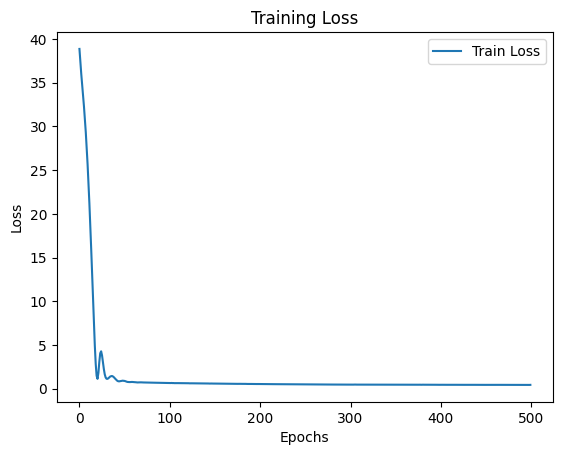

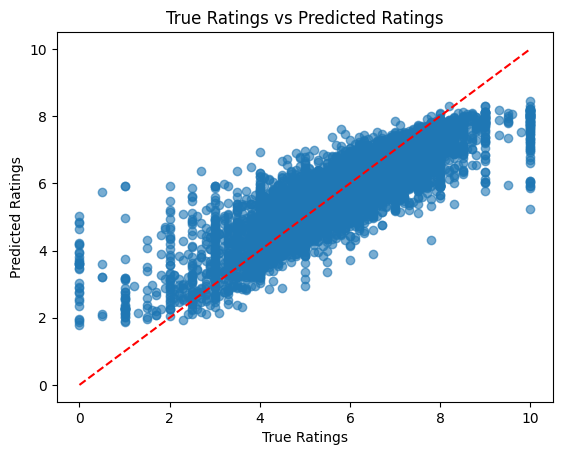

Mean Squared Error: 0.4375
R^2 Score for predictions: 0.7397822571421324


In [ ]:

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# 数据准备
X = movies_train_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
y = movies_train_df_selected['vote_average'].values

# 转换为 NumPy 数组
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

# 数据标准化
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# 转换为 Tensor
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # 增加维度
# 改进的 MLP 模型定义
class ImprovedMLP(nn.Module):
    def __init__(self, input_size):
        super(ImprovedMLP, self).__init__()

        # 主分支网络
        self.main_branch = nn.Sequential(
            nn.Linear(input_size, 256),      # 增加隐藏层1的神经元数量
            nn.BatchNorm1d(256),             # 批归一化
            nn.LeakyReLU(negative_slope=0.01),  # 使用 LeakyReLU 激活函数
            nn.Dropout(0.4),                 # 增加 Dropout 比例

            nn.Linear(256, 128),             # 隐藏层1到隐藏层2
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),              # 隐藏层2到隐藏层3
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),               # 隐藏层3到隐藏层4
            nn.BatchNorm1d(32),
            nn.ReLU()
        )

        # 辅助分支网络
        self.aux_branch = nn.Sequential(
            nn.Linear(input_size, 64),       # 辅助网络的隐藏层
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU()
        )

        # 输出层
        self.output_layer = nn.Sequential(
            nn.Linear(32 + 32, 16),          # 主分支和辅助分支的融合
            nn.ReLU(),
            nn.Linear(16, 1)                 # 最终输出
        )

    def forward(self, x):
        # 主分支输出
        main_output = self.main_branch(x)

        # 辅助分支输出
        aux_output = self.aux_branch(x)

        # 融合主分支和辅助分支的输出
        combined_output = torch.cat((main_output, aux_output), dim=1)

        # 输出层处理
        return self.output_layer(combined_output)

# 初始化改进版 MLP
input_size = X.shape[1]  # 输入特征数量
model = ImprovedMLP(input_size)

# 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.004, weight_decay=1e-3)  # 增加 L2 正则化

# 训练模型
num_epochs = 500
train_losses = []

for epoch in range(num_epochs):
    model.train()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}')

# 可视化训练损失
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss')
plt.show()

# 测试模型
X_test = movies_test_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
y_test_true = movies_test_df_selected['vote_average'].values

# 转换为 NumPy 数组并标准化
X_test = np.array(X_test, dtype=np.float32)
X_test = scaler.transform(X_test)

# 转换为 Tensor
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor).numpy()

# 可视化真实值 vs 预测值
plt.scatter(y_test_true, predictions, alpha=0.6)
plt.plot([0, 10], [0, 10], 'r--')  # 参考线
plt.xlabel('True Ratings')
plt.ylabel('Predicted Ratings')
plt.title('True Ratings vs Predicted Ratings')
plt.show()

# 打印均方误差
mse = mean_squared_error(y_test_true, predictions)
score = r2_score(y_test_true, predictions)
print(f'Mean Squared Error: {mse:.4f}')
print("R^2 Score for predictions:", score)

#Attention

Epoch [10/500], Train Loss: 4.5179
Epoch [20/500], Train Loss: 0.9045
Epoch [30/500], Train Loss: 1.3384
Epoch [40/500], Train Loss: 0.8771
Epoch [50/500], Train Loss: 0.7354
Epoch [60/500], Train Loss: 0.7234
Epoch [70/500], Train Loss: 0.7072
Epoch [80/500], Train Loss: 0.6949
Epoch [90/500], Train Loss: 0.6713
Epoch [100/500], Train Loss: 0.6688
Epoch [110/500], Train Loss: 0.6573
Epoch [120/500], Train Loss: 0.6430
Epoch [130/500], Train Loss: 0.6230
Epoch [140/500], Train Loss: 0.6118
Epoch [150/500], Train Loss: 0.6023
Epoch [160/500], Train Loss: 0.5849
Epoch [170/500], Train Loss: 0.5764
Epoch [180/500], Train Loss: 0.5702
Epoch [190/500], Train Loss: 0.5622
Epoch [200/500], Train Loss: 0.5549
Epoch [210/500], Train Loss: 0.5475
Epoch [220/500], Train Loss: 0.5388
Epoch [230/500], Train Loss: 0.5322
Epoch [240/500], Train Loss: 0.5237
Epoch [250/500], Train Loss: 0.5161
Epoch [260/500], Train Loss: 0.5119
Epoch [270/500], Train Loss: 0.4990
Epoch [280/500], Train Loss: 0.4985
E

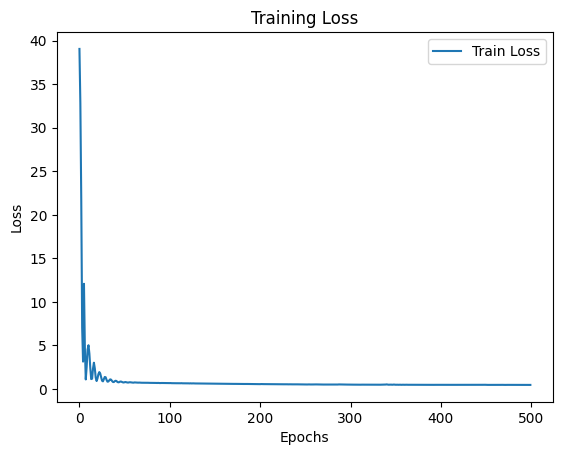

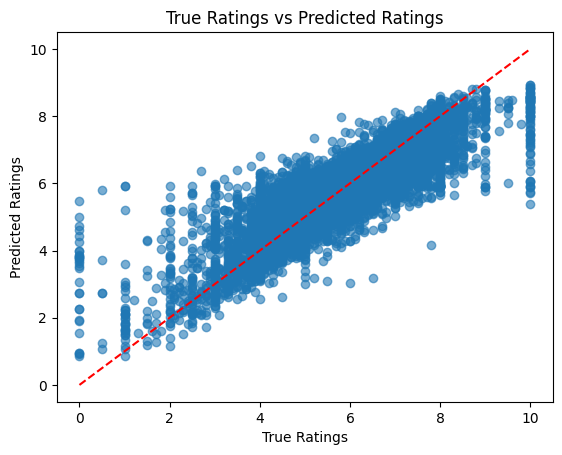

Mean Squared Error: 0.4313
R^2 Score for predictions: 0.7434249714259005


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# 数据准备
X = movies_train_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
y = movies_train_df_selected['vote_average'].values

# 转换为 NumPy 数组
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

# 数据标准化
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# 转换为 Tensor
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # 增加维度

# 改进的 Attention 模型定义
class ImprovedAttentionModel(nn.Module):
    def __init__(self, input_size, embed_dim, num_heads, hidden_dim, num_layers):
        super(ImprovedAttentionModel, self).__init__()

        # 主分支网络：Attention 提取特征
        self.main_attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=0.3, batch_first=True)
        self.main_fc = nn.Sequential(
            nn.Linear(input_size, embed_dim),  # 初始映射到 embed_dim
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )

        # 辅助分支网络：简单的全连接层
        self.aux_branch = nn.Sequential(
            nn.Linear(input_size, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        # 输出层
        self.output_layer = nn.Sequential(
            nn.Linear(embed_dim + hidden_dim, 64),  # 融合主分支和辅助分支
            nn.ReLU(),
            nn.Linear(64, 1)  # 最终输出
        )

    def forward(self, x):
        # 主分支：使用 Attention
        x_embedded = self.main_fc(x).unsqueeze(1)  # 增加序列维度
        main_output, _ = self.main_attention(x_embedded, x_embedded, x_embedded)
        main_output = main_output.squeeze(1)  # 移除序列维度

        # 辅助分支
        aux_output = self.aux_branch(x)

        # 融合主分支和辅助分支
        combined_output = torch.cat((main_output, aux_output), dim=1)

        # 输出层处理
        return self.output_layer(combined_output)

# 初始化改进版 Attention 模型
input_size = X.shape[1]  # 输入特征数量
embed_dim = 64  # Attention 的嵌入维度
num_heads = 4  # Attention 头数
hidden_dim = 256  # 辅助分支隐藏层维度
num_layers = 4  # 可选：用于深层网络
model = ImprovedAttentionModel(input_size, embed_dim, num_heads, hidden_dim, num_layers)

# 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# 训练模型
num_epochs = 500
train_losses = []

for epoch in range(num_epochs):
    model.train()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}')

# 可视化训练损失
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss')
plt.show()

# 测试模型
X_test = movies_test_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
y_test_true = movies_test_df_selected['vote_average'].values

# 转换为 NumPy 数组并标准化
X_test = np.array(X_test, dtype=np.float32)
X_test = scaler.transform(X_test)

# 转换为 Tensor
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor).numpy()

# 可视化真实值 vs 预测值
plt.scatter(y_test_true, predictions, alpha=0.6)
plt.plot([0, 10], [0, 10], 'r--')  # 参考线
plt.xlabel('True Ratings')
plt.ylabel('Predicted Ratings')
plt.title('True Ratings vs Predicted Ratings')
plt.show()

# 打印均方误差
mse = mean_squared_error(y_test_true, predictions)
score = r2_score(y_test_true, predictions)
print(f'Mean Squared Error: {mse:.4f}')
print("R^2 Score for predictions:", score)

#Machine Learning

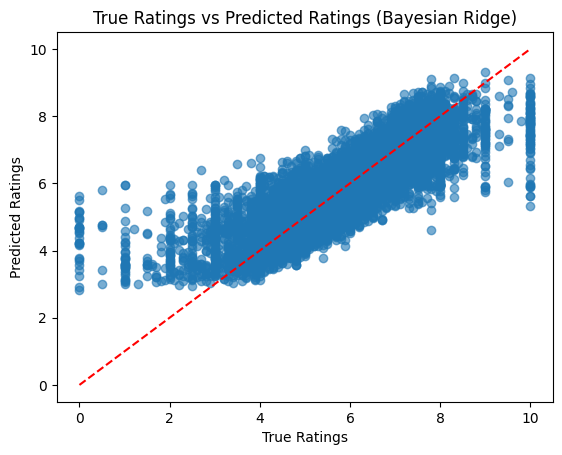

Mean Squared Error: 0.5501
R^2 Score for predictions: 0.6727579064957031


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Select the Data
X = movies_train_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
y = movies_train_df_selected['vote_average'].values

# Convert to Numpy
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

# Transformation
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Define the model
model = BayesianRidge()

# Training
model.fit(X, y)
train_predictions = model.predict(X)

# Testing
X_test = movies_test_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
y_test_true = movies_test_df_selected['vote_average'].values
X_test = np.array(X_test, dtype=np.float32)
X_test = scaler.transform(X_test)
test_predictions = model.predict(X_test)

# True Ratings vs Predicted Ratings
plt.scatter(y_test_true, test_predictions, alpha=0.6)
plt.plot([0, 10], [0, 10], 'r--')
plt.xlabel('True Ratings')
plt.ylabel('Predicted Ratings')
plt.title('True Ratings vs Predicted Ratings (Bayesian Ridge)')
plt.show()

# Error
mse = mean_squared_error(y_test_true, test_predictions)
score = r2_score(y_test_true, test_predictions)
print(f'Mean Squared Error: {mse:.4f}')
print("R^2 Score for predictions:", score)

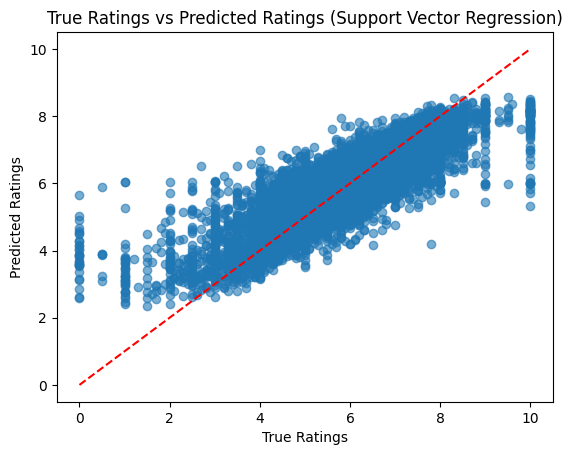

Mean Squared Error: 0.4523
R^2 Score for predictions: 0.7309312786047946


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Select the Data
X = movies_train_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
y = movies_train_df_selected['vote_average'].values

# Convert to Numpy
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

# Transformation
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Define the model
model = SVR(kernel='rbf', C=1.0, epsilon=0.2)

# Training
model.fit(X, y)
train_predictions = model.predict(X)

# Testing
X_test = movies_test_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
y_test_true = movies_test_df_selected['vote_average'].values
X_test = np.array(X_test, dtype=np.float32)
X_test = scaler.transform(X_test)
test_predictions = model.predict(X_test)

# True Ratings vs Predicted Ratings
plt.scatter(y_test_true, test_predictions, alpha=0.6)
plt.plot([0, 10], [0, 10], 'r--')
plt.xlabel('True Ratings')
plt.ylabel('Predicted Ratings')
plt.title('True Ratings vs Predicted Ratings (Support Vector Regression)')
plt.show()

# Error
mse = mean_squared_error(y_test_true, test_predictions)
score = r2_score(y_test_true, test_predictions)
print(f'Mean Squared Error: {mse:.4f}')
print("R^2 Score for predictions:", score)

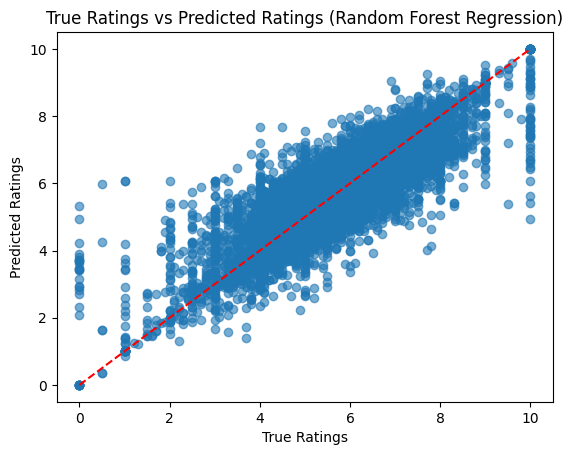

Mean Squared Error: 0.4497
R^2 Score for predictions: 0.7324830174769681


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Select the Data
X = movies_train_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
y = movies_train_df_selected['vote_average'].values

# Convert to Numpy
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

# Transformation
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Define the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Training
model.fit(X, y)
train_predictions = model.predict(X)

# Testing
X_test = movies_test_df_selected[['genres', 'keywords', 'production_companies', 'spoken_languages', 'production_countries', 'cast','crew']].values
y_test_true = movies_test_df_selected['vote_average'].values
X_test = np.array(X_test, dtype=np.float32)
X_test = scaler.transform(X_test)
test_predictions = model.predict(X_test)

# True Ratings vs Predicted Ratings
plt.scatter(y_test_true, test_predictions, alpha=0.6)
plt.plot([0, 10], [0, 10], 'r--')  # 参考线
plt.xlabel('True Ratings')
plt.ylabel('Predicted Ratings')
plt.title('True Ratings vs Predicted Ratings (Random Forest Regression)')
plt.show()

# Error
mse = mean_squared_error(y_test_true, test_predictions)
score = r2_score(y_test_true, test_predictions)
print(f'Mean Squared Error: {mse:.4f}')
print("R^2 Score for predictions:", score)